In [1]:
!pip install tensorflow numpy pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import re
import pickle 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense

In [3]:
text = """
machine learning is a part of artificial intelligence
machine learning allows computers to learn from data
artificial intelligence is changing the world
natural language processing helps computers understand human language
natural language processing is an important field of artificial intelligence
deep learning is a part of machine learning
machine learning is used in many real world applications
artificial intelligence helps people solve complex problems
data science is used to analyze large amounts of data
python is a popular programming language
python is widely used for machine learning
python is useful for natural language processing
"""

print(text)


machine learning is a part of artificial intelligence
machine learning allows computers to learn from data
artificial intelligence is changing the world
natural language processing helps computers understand human language
natural language processing is an important field of artificial intelligence
deep learning is a part of machine learning
machine learning is used in many real world applications
artificial intelligence helps people solve complex problems
data science is used to analyze large amounts of data
python is a popular programming language
python is widely used for machine learning
python is useful for natural language processing



In [4]:
with open("dataset.txt","r",encoding="utf-8")as file:
    text = file.read()


FileNotFoundError: [Errno 2] No such file or directory: 'dataset.txt'

In [7]:
text=text.lower()
text=re.sub(r'[^a-zA-Z\s]', '',text)
text=re.sub(r'\s+', ' ',text).strip()

print(text)

machine learning is a part of artificial intelligence machine learning allows computers to learn from data artificial intelligence is changing the world natural language processing helps computers understand human language natural language processing is an important field of artificial intelligence deep learning is a part of machine learning machine learning is used in many real world applications artificial intelligence helps people solve complex problems data science is used to analyze large amounts of data python is a popular programming language python is widely used for machine learning python is useful for natural language processing


In [12]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts([text])
total_words=len(tokenizer.word_index)+1
print("Total vocabulary size:", total_words)
print("\nWord Index:")
print(tokenizer.word_index)

Total vocabulary size: 47

Word Index:
{'is': 1, 'learning': 2, 'machine': 3, 'language': 4, 'of': 5, 'artificial': 6, 'intelligence': 7, 'a': 8, 'data': 9, 'natural': 10, 'processing': 11, 'used': 12, 'python': 13, 'part': 14, 'computers': 15, 'to': 16, 'world': 17, 'helps': 18, 'for': 19, 'allows': 20, 'learn': 21, 'from': 22, 'changing': 23, 'the': 24, 'understand': 25, 'human': 26, 'an': 27, 'important': 28, 'field': 29, 'deep': 30, 'in': 31, 'many': 32, 'real': 33, 'applications': 34, 'people': 35, 'solve': 36, 'complex': 37, 'problems': 38, 'science': 39, 'analyze': 40, 'large': 41, 'amounts': 42, 'popular': 43, 'programming': 44, 'widely': 45, 'useful': 46}


In [13]:
input_sequences = []

words = text.split()

for i in range(1, len(words)):
    sequence = words[:i+1]
    encoded_sequence = tokenizer.texts_to_sequences([' '.join(sequence)])[0]
    input_sequences.append(encoded_sequence)

print("Number of sequences:", len(input_sequences))

print("\nFirst 10 sequences:")
for sequence in input_sequences[:10]:
    print(sequence)

Number of sequences: 93

First 10 sequences:
[3, 2]
[3, 2, 1]
[3, 2, 1, 8]
[3, 2, 1, 8, 14]
[3, 2, 1, 8, 14, 5]
[3, 2, 1, 8, 14, 5, 6]
[3, 2, 1, 8, 14, 5, 6, 7]
[3, 2, 1, 8, 14, 5, 6, 7, 3]
[3, 2, 1, 8, 14, 5, 6, 7, 3, 2]
[3, 2, 1, 8, 14, 5, 6, 7, 3, 2, 20]


In [14]:
max_sequence_length = max(len(sequence) for sequence in input_sequences)

print("Maximum sequence length:", max_sequence_length)

Maximum sequence length: 94


In [15]:
input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding='pre'
)

print("Shape:", input_sequences.shape)

print("\nFirst 10 padded sequences:")
print(input_sequences[:10])

Shape: (93, 94)

First 10 padded sequences:
[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  2]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  2  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  2  1  8]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  

In [16]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (93, 93)
y shape: (93,)


In [17]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=total_words)

print("New y shape:", y.shape)

New y shape: (93, 47)


In [18]:
model = Sequential()

model.add(
    Embedding(
        input_dim=total_words,
        output_dim=100,
        input_length=max_sequence_length - 1
    )
)

model.add(
    LSTM(150)
)

model.add(
    Dense(total_words, activation='softmax')
)

model.summary()

C:\Users\acer\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape         ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ embedding (Embedding)       │ ?                    │ 0 (unbuilt) │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ lstm (LSTM)                 │ ?                    │ 0 (unbuilt) │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ dense (Dense)               │ ?                    │ 0 (unbuilt) │
└─────────────────────────────┴──────────────────────┴─────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Dataset:

machine learning is a part of artificial intelligence
machine learning allows computers to learn from data
artificial intelligence is changing the world
artificial intelligence helps people solve complex problems
natural language processing helps computers understand human language
natural language processing is an important field of artificial intelligence
deep learning is a part of machine learning
deep learning uses neural networks to learn from data
machine learning is used in many real world applications
machine learning can analyze large amounts of data
python is a popular programming language
python is widely used for machine learning
python is useful for natural language processing
data science is used to analyze large amounts of data
data science and machine learning work together
computers can learn patterns from data
artificial intelligence can help people in many ways
natural language processing works with human language
machine learning models learn from examples

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape         ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)     │ ?                    │ 0 (unbuilt) │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ lstm_1 (LSTM)               │ ?                    │ 0 (unbuilt) │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ dense_1 (Dense)             │ ?                    │ 0 (unbuilt) │
└─────────────────────────────┴──────────────────────┴─────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.0265 - loss: 4.1098
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.0795 - loss: 4.0855
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.0728 - loss: 3.9847
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.0728 - loss: 3.8930
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.0728 - loss: 3.8345
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.0728 - loss: 3.8108
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.1126 - loss: 3.7895
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.0927 - loss: 3.7564
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.0795 - loss: 3.7236
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.1126 - loss: 3.6887
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.1126 - loss: 3.6313
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.

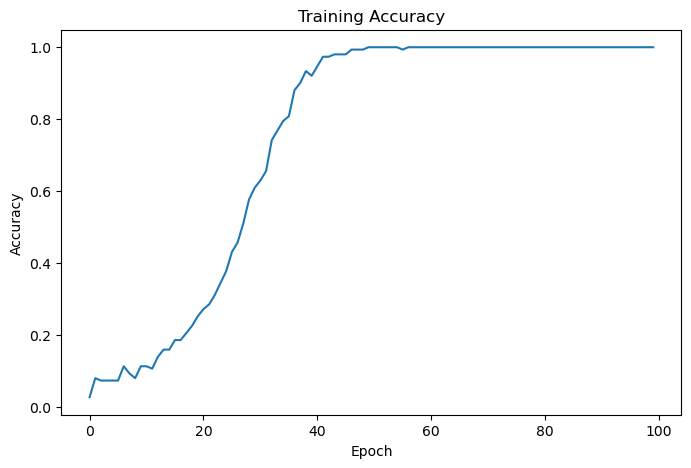

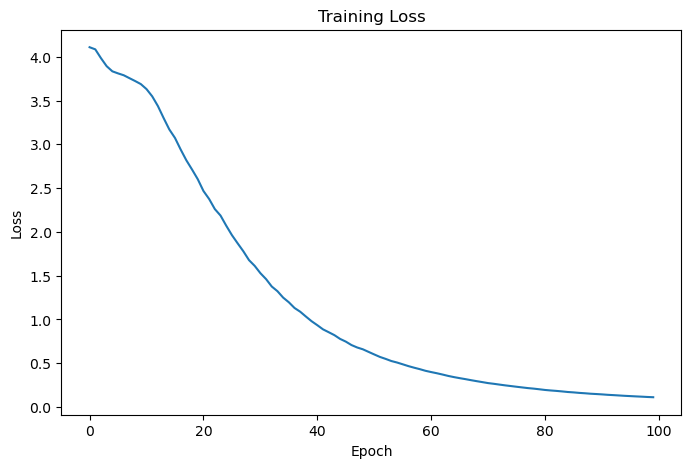

Input Sentence: machine learning
Predicted Next Word: is
machine learning → is
artificial intelligence → is
natural language → machine
python is → a
deep learning → is
Original Text:
machine learning

Generated Text:
machine learning is a part of artificial

Model saved successfully!
Tokenizer saved successfully!



Enter a sentence:  python is a



Predicted Next Word: part


In [19]:
# ============================================================
# SMART NEXT-WORD PREDICTOR USING NLP + LSTM
# ============================================================

# CELL 1: Install required libraries
# Run this only if the libraries are not already installed.

!pip install tensorflow numpy matplotlib


# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import numpy as np
import re
import pickle
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense

from tensorflow.keras.utils import to_categorical


# ============================================================
# CELL 3: CREATE DATASET
# ============================================================

text = """
machine learning is a part of artificial intelligence
machine learning allows computers to learn from data
artificial intelligence is changing the world
artificial intelligence helps people solve complex problems
natural language processing helps computers understand human language
natural language processing is an important field of artificial intelligence
deep learning is a part of machine learning
deep learning uses neural networks to learn from data
machine learning is used in many real world applications
machine learning can analyze large amounts of data
python is a popular programming language
python is widely used for machine learning
python is useful for natural language processing
data science is used to analyze large amounts of data
data science and machine learning work together
computers can learn patterns from data
artificial intelligence can help people in many ways
natural language processing works with human language
machine learning models learn from examples
deep learning models can understand complex patterns
"""


print("Dataset:")
print(text)


# ============================================================
# CELL 4: TEXT PREPROCESSING
# ============================================================

# Convert all text to lowercase
text = text.lower()

# Remove unwanted characters
text = re.sub(r'[^a-zA-Z\s]', '', text)

# Remove extra spaces
text = re.sub(r'\s+', ' ', text).strip()

print("\nCleaned Text:")
print(text)


# ============================================================
# CELL 5: TOKENIZATION
# ============================================================

tokenizer = Tokenizer()

# Learn the vocabulary from our dataset
tokenizer.fit_on_texts([text])

# Number of words in vocabulary
total_words = len(tokenizer.word_index) + 1

print("\nTotal Vocabulary Size:", total_words)

print("\nWord Index:")
print(tokenizer.word_index)


# ============================================================
# CELL 6: CREATE TRAINING SEQUENCES
# ============================================================

input_sequences = []

# Split the text into words
words = text.split()

# Create n-gram sequences
for i in range(1, len(words)):
    
    sequence = words[:i + 1]
    
    encoded_sequence = tokenizer.texts_to_sequences(
        [' '.join(sequence)]
    )[0]
    
    input_sequences.append(encoded_sequence)


print("\nTotal Sequences:", len(input_sequences))

print("\nFirst 10 Sequences:")

for sequence in input_sequences[:10]:
    print(sequence)


# ============================================================
# CELL 7: FIND MAXIMUM SEQUENCE LENGTH
# ============================================================

max_sequence_length = max(
    len(sequence)
    for sequence in input_sequences
)

print("\nMaximum Sequence Length:", max_sequence_length)


# ============================================================
# CELL 8: PADDING
# ============================================================

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding='pre'
)

print("\nPadded Sequence Shape:", input_sequences.shape)

print("\nFirst 10 Padded Sequences:")

print(input_sequences[:10])


# ============================================================
# CELL 9: SPLIT INPUT X AND TARGET Y
# ============================================================

# All values except the last word
X = input_sequences[:, :-1]

# Last word becomes the target
y = input_sequences[:, -1]

print("\nX Shape:", X.shape)
print("Y Shape:", y.shape)


# ============================================================
# CELL 10: ONE-HOT ENCODING
# ============================================================

y = to_categorical(
    y,
    num_classes=total_words
)

print("\nAfter One-Hot Encoding:")
print("X Shape:", X.shape)
print("Y Shape:", y.shape)


# ============================================================
# CELL 11: BUILD LSTM MODEL
# ============================================================

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=total_words,
        output_dim=100
    )
)

# LSTM Layer
model.add(
    LSTM(150)
)

# Output Layer
model.add(
    Dense(
        total_words,
        activation='softmax'
    )
)


# Display model architecture
model.summary()


# ============================================================
# CELL 12: COMPILE MODEL
# ============================================================

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


# ============================================================
# CELL 13: TRAIN MODEL
# ============================================================

history = model.fit(
    X,
    y,
    epochs=100,
    batch_size=32,
    verbose=1
)


# ============================================================
# CELL 14: PLOT TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy']
)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()


# ============================================================
# CELL 15: PLOT TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss']
)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()


# ============================================================
# CELL 16: NEXT-WORD PREDICTION FUNCTION
# ============================================================

def predict_next_word(seed_text):

    # Convert input to lowercase
    seed_text = seed_text.lower()

    # Convert words into numbers
    token_list = tokenizer.texts_to_sequences(
        [seed_text]
    )[0]

    # Check whether words exist in vocabulary
    if len(token_list) == 0:
        return None

    # Padding
    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_length - 1,
        padding='pre'
    )

    # Predict probabilities
    predicted_probabilities = model.predict(
        token_list,
        verbose=0
    )

    # Find the word with highest probability
    predicted_word_index = np.argmax(
        predicted_probabilities,
        axis=-1
    )[0]

    # Convert number back to word
    for word, index in tokenizer.word_index.items():

        if index == predicted_word_index:
            return word

    return None


# ============================================================
# CELL 17: TEST NEXT-WORD PREDICTION
# ============================================================

test_sentence = "machine learning"

predicted_word = predict_next_word(
    test_sentence
)

print("Input Sentence:", test_sentence)

print("Predicted Next Word:", predicted_word)


# ============================================================
# CELL 18: TEST MULTIPLE SENTENCES
# ============================================================

sentences = [
    "machine learning",
    "artificial intelligence",
    "natural language",
    "python is",
    "deep learning"
]

for sentence in sentences:

    prediction = predict_next_word(sentence)

    print(
        sentence,
        "→",
        prediction
    )


# ============================================================
# CELL 19: PREDICT MULTIPLE WORDS
# ============================================================

def predict_multiple_words(
    seed_text,
    number_of_words=5
):

    result = seed_text

    for i in range(number_of_words):

        next_word = predict_next_word(
            result
        )

        if next_word is None:
            break

        result = result + " " + next_word

    return result


# ============================================================
# CELL 20: TEST MULTIPLE-WORD PREDICTION
# ============================================================

input_text = "machine learning"

generated_text = predict_multiple_words(
    input_text,
    number_of_words=5
)

print("Original Text:")
print(input_text)

print("\nGenerated Text:")
print(generated_text)


# ============================================================
# CELL 21: SAVE TRAINED MODEL
# ============================================================

model.save(
    "next_word_predictor.keras"
)

print(
    "\nModel saved successfully!"
)


# ============================================================
# CELL 22: SAVE TOKENIZER
# ============================================================

with open(
    "tokenizer.pkl",
    "wb"
) as file:

    pickle.dump(
        tokenizer,
        file
    )

print(
    "Tokenizer saved successfully!"
)


# ============================================================
# CELL 23: FINAL USER INPUT
# ============================================================

user_input = input(
    "\nEnter a sentence: "
)

prediction = predict_next_word(
    user_input
)

print(
    "\nPredicted Next Word:",
    prediction
)